In [5]:
# Import Libraries

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Suppress warning messages for clean notebook execution
warnings.filterwarnings('ignore')

# Set Visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Color
NAVY = '#1F3864'
AMBER = '#E8A33D'
PALETTE = [NAVY, AMBER, '#5B8FB9', '#C0504D', '#9BBB59', '#8064A2']
sns.set_palette(sns.color_palette(PALETTE))

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 150)


In [12]:
# Data From Load Excel
# - '161,945' rows across all 11 files

Cities = r"E:\Global Restaurant & Food Delivery Intelligence Dataset\data\cities.csv"
df1 = pd.read_csv(Cities)
print(df1)

City_statistics = r"E:\Global Restaurant & Food Delivery Intelligence Dataset\data\city_statistics.csv"
df2 = pd.read_csv(City_statistics)
print(df2)

Countries = r"E:\Global Restaurant & Food Delivery Intelligence Dataset\data\countries.csv"
df3 = pd.read_csv(Countries)
print(df3)

Cuisines = r"E:\Global Restaurant & Food Delivery Intelligence Dataset\data\cuisines.csv"
df4 = pd.read_csv(Cuisines)
print(df4)

Delivery_metrics = r"E:\Global Restaurant & Food Delivery Intelligence Dataset\data\delivery_metrics.csv"
df5 = pd.read_csv(Delivery_metrics)
print(df5)

Menus = r"E:\Global Restaurant & Food Delivery Intelligence Dataset\data\menus.csv"
df6 = pd.read_csv(Menus)
print(df6)

Nutrition = r"E:\Global Restaurant & Food Delivery Intelligence Dataset\data\nutrition.csv"
df7 = pd.read_csv(Nutrition)
print(df7)

Price_history = r"E:\Global Restaurant & Food Delivery Intelligence Dataset\data\price_history.csv"
df8 = pd.read_csv(Price_history)
print(df8)

Restaurent_features = r"E:\Global Restaurant & Food Delivery Intelligence Dataset\data\restaurant_features.csv"
df9 = pd.read_csv(Restaurent_features)
print(df9)

Restaurent_statistics = r"E:\Global Restaurant & Food Delivery Intelligence Dataset\data\restaurant_statistics.csv"
df10 = pd.read_csv(Restaurent_statistics)
print(df10)

Restaurents = r"E:\Global Restaurant & Food Delivery Intelligence Dataset\data\restaurants.csv"
df11 = pd.read_csv(Restaurents)
print(df11)


             City         Country  Population  Area_km2  Urban_density  Tourism_index  Average_income  Cost_of_living_index          Weather_zone
0        New York             USA     8419000     783.8          10700            1.2           85000                   100     Humid subtropical
1     Los Angeles             USA     3898000    1302.0           2990            1.1           75000                    95         Mediterranean
2          London  United Kingdom     8982000    1572.0           5700            1.3           50000                    90               Oceanic
3      Manchester  United Kingdom      552000     115.0           4800            0.8           35000                    75               Oceanic
4          Mumbai           India    12442000     603.0          20633            0.9           15000                    40  Tropical wet and dry
5           Delhi           India    16787000    1484.0          11312            1.1           14000                    38 

In [18]:
# Data Overview & Quality Check
tables_df = {
    'Cities': df1,
    'City_statistics' : df2,
    'Countries' : df3,
    'Cuisines' : df4,
    'Delivery_metrics' : df5,
    'Menus' : df6,
    'Nutrition' : df7,
    'Price_history' : df8,
    'Restaurent_features' : df9,
    'Restaurent_statistics' : df10,
    'Restaurents' : df11
}

In [21]:
# 1. Shape, missing values, duplicates summary
overview = pd.DataFrame({
    'rows': {k: len(v) for k, v in tables.items()},
    'columns': {k: v.shape[1] for k, v in tables.items()},
    'missing_values': {k: v.isnull().sum().sum() for k, v in tables.items()},
    'duplicate_rows': {k: v.duplicated().sum() for k, v in tables.items()}
})
print(overview.sort_values('rows', ascending=False))
print(f"\nTotal rows across all files: {sum(len(t) for t in tables.values()):,}")

                        rows  columns  missing_values  duplicate_rows
Nutrition              62417       11               0               0
Menus                  62417       15               0               0
Price_history          18887        5               0               0
Restaurent_statistics   5000        6            1813               0
Restaurents             5000       17               0               0
Restaurent_features     5000       14               0               0
Delivery_metrics        3187       10               0               0
Cuisines                  12        4               0               0
Cities                    10        9               0               0
City_statistics           10        7               0               0
Countries                  5        6               0               0

Total rows across all files: 161,945


In [27]:
# 2. Data types per table
for name, df in tables.items():
    print(f"\n--- {name} dtypes ---")
    print(df.dtypes)

# 3. Missing values breakdown (only columns with nulls)
print("=== MISSING VALUES BY COLUMN ===")
for name, df in tables.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f"\n--- {name} ---")
        print(nulls)
        print(f"% missing: {(nulls / len(df) * 100).round(2).to_dict()}")


--- Cities dtypes ---
City                     object
Country                  object
Population                int64
Area_km2                float64
Urban_density             int64
Tourism_index           float64
Average_income            int64
Cost_of_living_index      int64
Weather_zone             object
dtype: object

--- City_statistics dtypes ---
City                        object
Country                     object
Restaurant_density         float64
Cuisine_diversity_index    float64
Average_rating             float64
Average_menu_price         float64
Delivery_coverage          float64
dtype: object

--- Countries dtypes ---
Country         object
Region          object
Income_group    object
Currency        object
Timezone        object
ISO_code        object
dtype: object

--- Cuisines dtypes ---
Cuisine_ID        object
Cuisine_name      object
Parent_cuisine    object
Region            object
dtype: object

--- Delivery_metrics dtypes ---
Restaurant_ID               object

In [28]:
df.describe()

,Latitude,Longitude,Opening_year,Price_level,Average_rating,Review_count
count,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000
mean,0.188168,-0.685162,1986.1926,2.491200,3.504680,2505.615200
std,51.573437,104.039439,21.4516,1.123109,0.877383,1451.405121
min,-89.997219,-179.979525,1950.0000,1.000000,2.000000,0.000000
25%,-43.587712,-89.827104,1967.0000,1.000000,2.800000,1236.750000
50%,0.686586,-1.102218,1986.0000,2.000000,3.500000,2507.500000
75%,44.377998,88.248740,2005.0000,4.000000,4.300000,3744.000000
max,89.988704,179.768773,2023.0000,4.000000,5.000000,5000.000000


In [71]:
# -------------------------------------- 1.CITIES & COUNTRIES-------------------------
print(df1.head())
print(df2.head())
print(df3.head())

          City         Country  Population  Area_km2  Urban_density  Tourism_index  Average_income  Cost_of_living_index          Weather_zone
0     New York             USA     8419000     783.8          10700            1.2           85000                   100     Humid subtropical
1  Los Angeles             USA     3898000    1302.0           2990            1.1           75000                    95         Mediterranean
2       London  United Kingdom     8982000    1572.0           5700            1.3           50000                    90               Oceanic
3   Manchester  United Kingdom      552000     115.0           4800            0.8           35000                    75               Oceanic
4       Mumbai           India    12442000     603.0          20633            0.9           15000                    40  Tropical wet and dry
          City         Country  Restaurant_density  Cuisine_diversity_index  Average_rating  Average_menu_price  Delivery_coverage
0     New Y

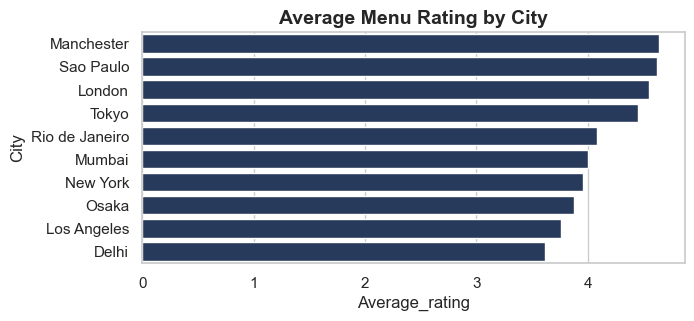

In [51]:
# Average Menu Rating Vy City
plt.figure(figsize =(7,3))
sns.barplot(data=df2.sort_values('Average_rating', ascending= False), x= 'Average_rating', y= 'City')
plt.title('Average Menu Rating by City')
plt.show()

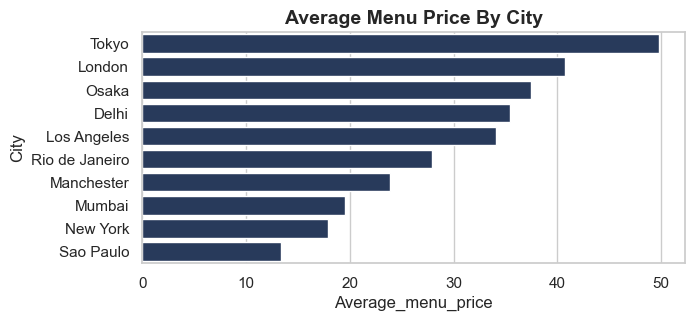

In [55]:
# Average Munu Price By City
plt.figure(figsize =(7,3))
sns.barplot(data = df2.sort_values('Average_menu_price', ascending = False), x = 'Average_menu_price', y = 'City')
plt.title('Average Menu Price By City')
plt.show()

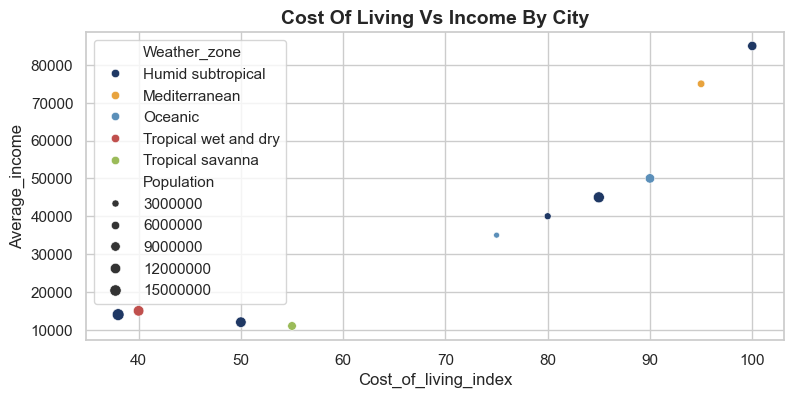

In [66]:
#Cost Of Living Vs Income By City
plt.figure(figsize = (9,4))
sns.scatterplot(data = df1, x = 'Cost_of_living_index', y = 'Average_income', size = 'Population', hue='Weather_zone')
plt.title('Cost Of Living Vs Income By City')
plt.show()

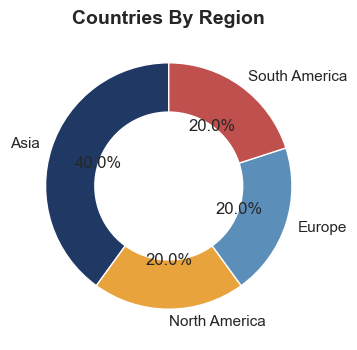

In [174]:
# Countries By Region

plt.figure(figsize = (7,4))
region_counts = df3['Region'].value_counts()
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%',
        startangle=90, wedgeprops={'width': 0.4})
plt.title('Countries By Region')
plt.show()

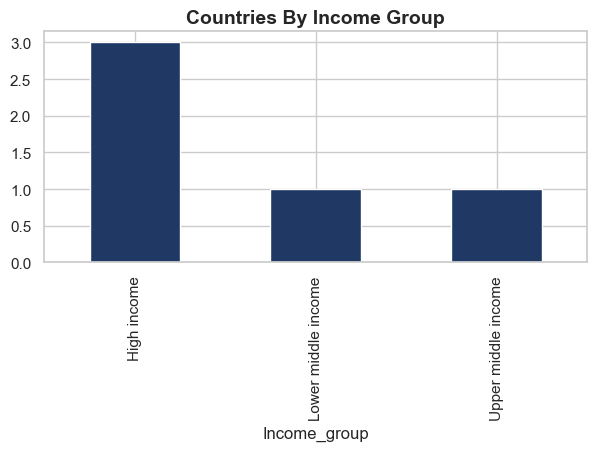

In [69]:
# Countries By Income Group
plt.figure(figsize = (7,3))
df3['Income_group'].value_counts().plot(kind = 'bar')
plt.title('Countries By Income Group')
plt.show()

In [73]:
# --------------------------2.CUISINE-----------------------------
print(df4.head())

  Cuisine_ID Cuisine_name  Parent_cuisine    Region
0     CUI000      Italian        European    Europe
1     CUI001      Chinese           Asian      Asia
2     CUI002      Mexican  Latin American  Americas
3     CUI003       Indian           Asian      Asia
4     CUI004     Japanese           Asian      Asia


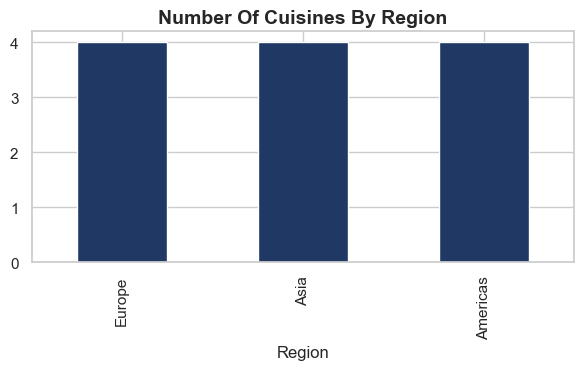

In [75]:
# Number Of Cuisines By Region
plt.figure(figsize= (7,3))
df4['Region'].value_counts().plot(kind = 'bar')
plt.title('Number Of Cuisines By Region')
plt.show()

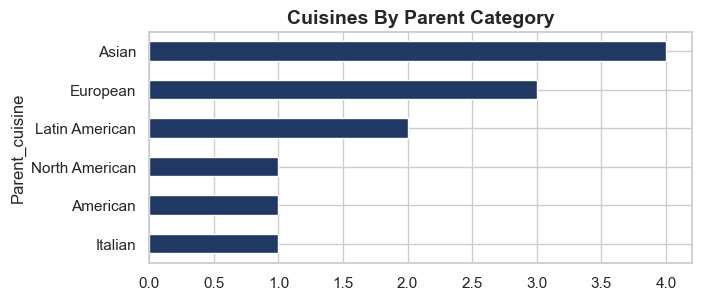

In [85]:
# Cuisines By Parent Category
plt.figure(figsize= (7,3))
df4['Parent_cuisine'].value_counts().plot(kind = 'barh')
plt.title('Cuisines By Parent Category')
plt.gca().invert_yaxis()                         # For Upper Side Y axis
plt.show()

In [89]:
#--------------------------------3. RESTAURENTS---------------------------------
print("---Business Status---")
print(df11['Business_status'].value_counts())
print("---Chain Local---")
print(df11['Chain_local'].value_counts())

---Business Status---
Business_status
Operational           4749
Closed Temporarily     251
Name: count, dtype: int64
---Chain Local---
Chain_local
Local    3515
Chain    1485
Name: count, dtype: int64


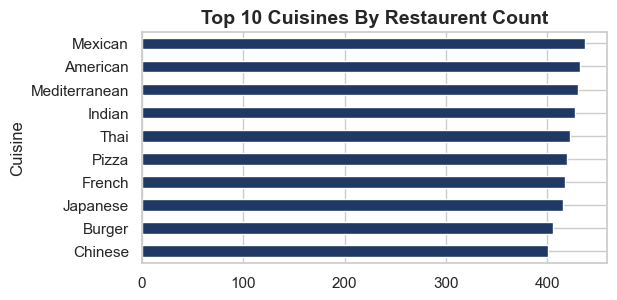

In [98]:
# Top 10 Cuisines By Restaurent Count

plt.figure(figsize = (6,3))
df11['Cuisine'].value_counts().head(10).plot(kind = 'barh')
plt.title('Top 10 Cuisines By Restaurent Count')
plt.gca().invert_yaxis()
plt.show()

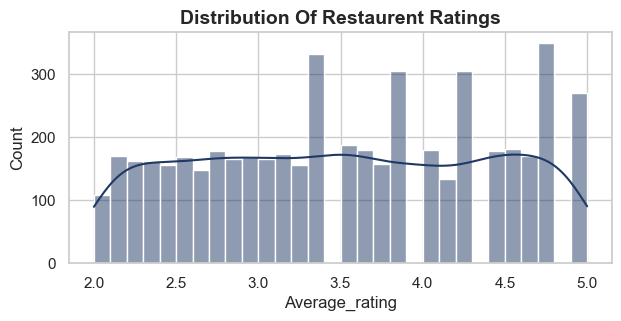

In [101]:
# Distribution Of Restaurent Ratings

plt.figure(figsize = (7,3))
sns.histplot(df11['Average_rating'],bins = 30, kde = True)
plt.title('Distribution Of Restaurent Ratings')
plt.show()

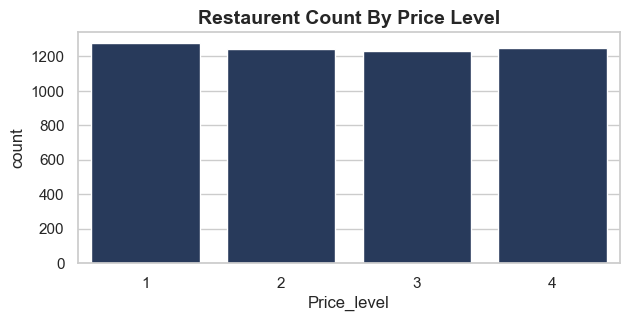

In [99]:
# Restaurent Count By Price Level

plt.figure(figsize = (7,3))
sns.countplot(df11, x= 'Price_level')
plt.title('Restaurent Count By Price Level')
plt.show()

In [102]:
# ---------------------------4. RESTAURANT FEATURES (AMENITIES)--------------------

feature_cols = ['Outdoor_seating', 'WiFi', 'Parking', 'Wheelchair_accessible',
                 'Pet_friendly', 'Kid_friendly', 'Vegetarian', 'Vegan',
                 'Halal', 'Alcohol', 'Drive_through', '24_hours', 'Live_music']

feature_percent = df9[feature_cols].mean() * 100
print(feature_percent.sort_values(ascending=False))

24_hours                 51.04
Vegan                    50.88
Vegetarian               50.28
Drive_through            50.04
Kid_friendly             49.88
Pet_friendly             49.86
Parking                  49.60
Live_music               49.46
Wheelchair_accessible    49.42
Outdoor_seating          49.38
Halal                    49.36
WiFi                     49.10
Alcohol                  48.86
dtype: float64


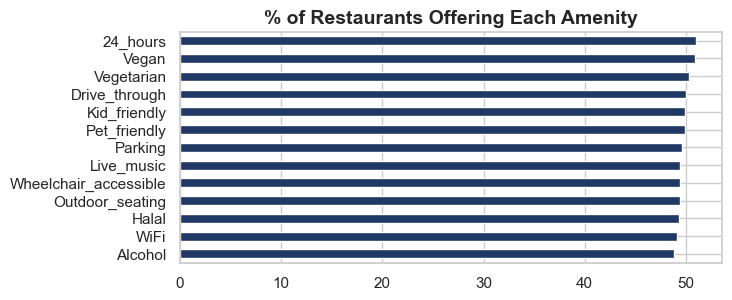

In [106]:
# Percentage of Restaurants Offering Each Amenity
plt.figure(figsize = (7,3))
feature_percent.sort_values(ascending=False).plot(kind='barh')
plt.title('% of Restaurants Offering Each Amenity')
plt.gca().invert_yaxis()
plt.show()

In [115]:
# ---------------------MENUS--------------------------------

print(df6['Food_category'].value_counts())
print("Vegetarian %:", df6['Vegetarian'].mean() * 100)
print("Vegan %:", df6['Vegan'].mean() * 100)
print("Gluten Free %:", df6['Gluten_free'].mean() * 100)

Food_category
Dessert     15721
Beverage    15627
Starter     15568
Main        15501
Name: count, dtype: int64
Vegetarian %: 50.06328404120672
Vegan %: 24.91789095919381
Gluten Free %: 49.987984042808854


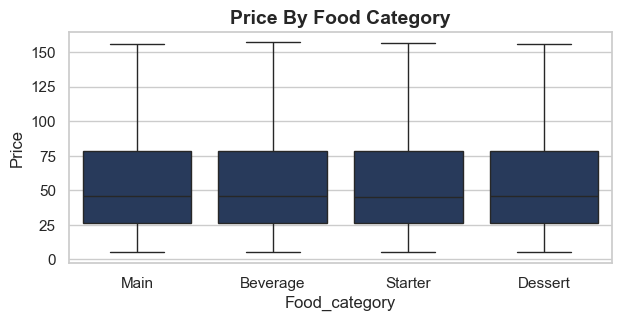

In [111]:
# Price By Food Category

plt.figure(figsize = (7,3))
sns.boxplot(data=df6, x='Food_category', y='Price', showfliers=False)
plt.title('Price By Food Category')#plt.xticks(rotation= 0)
plt.show()

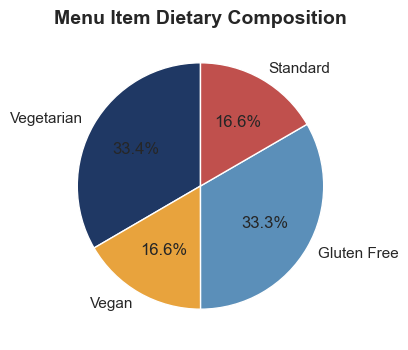

In [158]:
# Menu Item Dietary Composition

diet_counts = pd.Series({
    'Vegetarian': df6['Vegetarian'].sum(),
    'Vegan': df6['Vegan'].sum(),
    'Gluten Free': df6['Gluten_free'].sum(),
    'Standard': (~(df6['Vegetarian'] | df6['Vegan'] | df6['Gluten_free'])).sum()
})
plt.figure(figsize = (7,4))
diet_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Menu Item Dietary Composition')
plt.ylabel('')
plt.show()

In [119]:
# --------------------------NUTRITION----------------------------------

Nutrition_cols = ['Calories' , 'Protein', 'Fat', 'Carbohydrates' , 'Sugar', 'Sodium']
print(df7[Nutrition_cols].describe())

           Calories       Protein           Fat  Carbohydrates         Sugar        Sodium
count  62417.000000  62417.000000  62417.000000   62417.000000  62417.000000  62417.000000
mean     800.125078     50.100966     49.836216      75.120277     49.802112   1000.907474
std      404.949396     28.911530     28.796831      43.361510     28.860361    577.948346
min      100.000000      0.000000      0.000000       0.000000      0.000000      0.000000
25%      449.000000     25.000000     25.000000      37.300000     24.800000    499.400000
50%      803.000000     50.500000     49.700000      75.500000     49.800000   1000.600000
75%     1151.000000     75.000000     74.700000     112.700000     74.700000   1502.000000
max     1500.000000    100.000000    100.000000     150.000000    100.000000   2000.000000


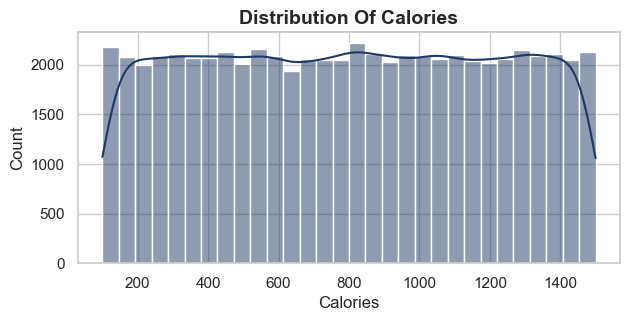

In [120]:
# Distribution Of Calories

plt.figure(figsize = (7,3))
sns.histplot(df7['Calories'], bins=30, kde=True)
plt.title('Distribution Of Calories')
plt.show()

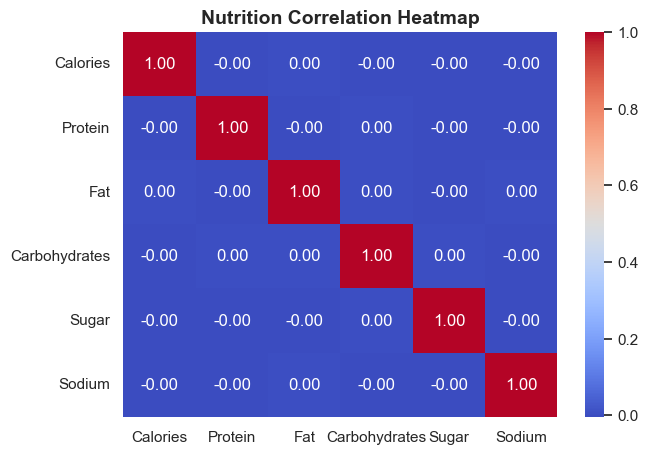

In [144]:
# Nutrition Correlation Heatmap

plt.figure(figsize=(7,5))
sns.heatmap(df7[Nutrition_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Nutrition Correlation Heatmap')
plt.show()

In [126]:
#----------------------------- PRICE HISTORY -

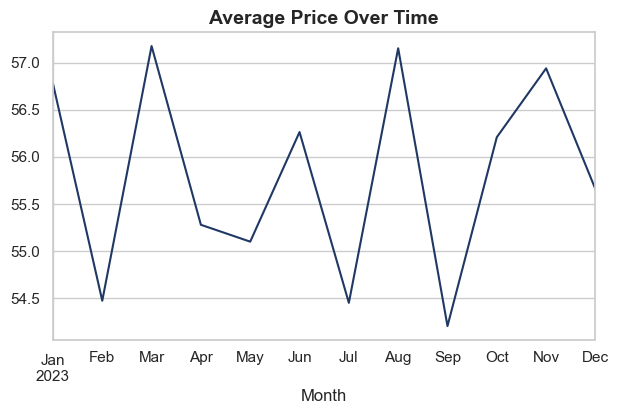

In [129]:
# Avergae Price Over Time

plt.figure(figsize = (7,4))
monthly_price.plot()
plt.title('Average Price Over Time')
plt.show()

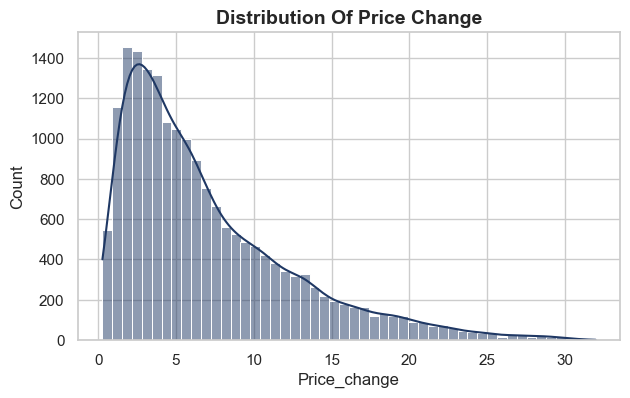

In [133]:
# Distribution Of Price Change

plt.figure(figsize = (7,4))
sns.histplot(df8['Price_change'], bins=50, kde=True)
plt.title('Distribution Of Price Change')
plt.show()

In [135]:
# Price Increase & Decrease

print("Price increases %:", (df8['Price_change'] > 0).mean() * 100)
print("Price decreases %:", (df8['Price_change'] < 0).mean() * 100)

Price increases %: 100.0
Price decreases %: 0.0


In [136]:
# ----------------------------------- DELIVERY METRICS-----------------------------

print(df5.describe())

       Delivery_fee  Service_fee  Packaging_fee  Estimated_delivery_time  Average_delivery_time  Peak_hour_multiplier  Minimum_order  \
count   3187.000000  3187.000000    3187.000000              3187.000000            3187.000000           3187.000000    3187.000000   
mean       5.076981     2.498080       0.977471                52.706621              55.541261              1.747170      12.442447   
std        2.877586     1.449728       0.578118                22.072646              22.478401              0.428927       7.234477   
min        0.010000     0.000000       0.000000                15.000000              10.000000              1.000000       0.000000   
25%        2.645000     1.260000       0.470000                34.000000              37.000000              1.370000       6.130000   
50%        5.130000     2.480000       0.980000                52.000000              55.000000              1.740000      12.260000   
75%        7.630000     3.740000       1.480000 

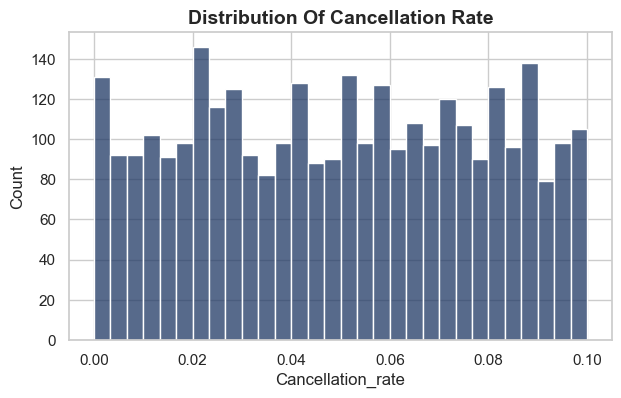

In [138]:
# Distribution Of Cancellation Rate

plt.figure(figsize = (7,4))
sns.histplot(df5['Cancellation_rate'], bins=30)
plt.title('Distribution Of Cancellation Rate')
plt.show()

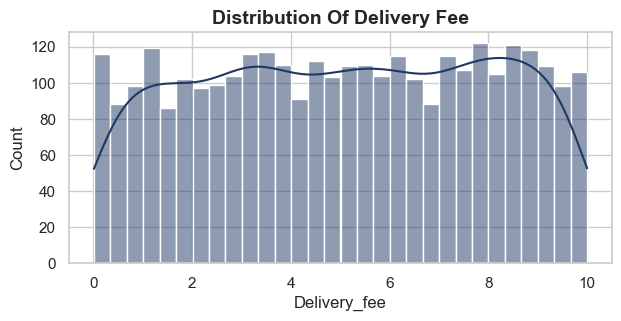

In [141]:
# Distribution of Delivery Fee

plt.figure(figsize = (7,3))
sns.histplot(df5['Delivery_fee'], bins=30, kde=True)
plt.title('Distribution Of Delivery Fee')
plt.show()

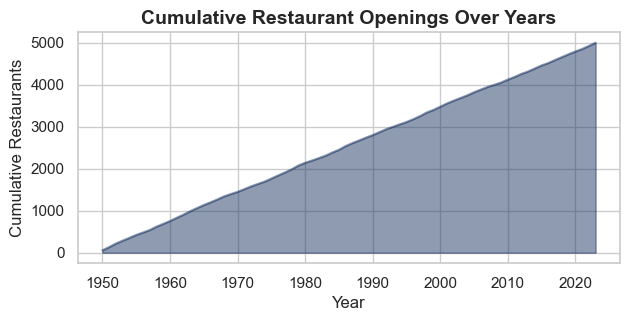

In [167]:
# Cumulative Restaurants

plt.figure(figsize = (7,3))
openings = df11['Opening_year'].value_counts().sort_index().cumsum()
openings.plot(kind='area', alpha=0.5, color='#1F3864')
plt.title('Cumulative Restaurant Openings Over Years')
plt.xlabel('Year')
plt.ylabel('Cumulative Restaurants')
plt.show()